# Factor Analysis Tutorial
## Intro
Factor analysis is a statistical method used to explain relationships between many observed variables using a smaller number of hidden variables (factors). So instead of analyzing each variable independently, we assume that some hidden structure is influencing them. 

### Factor Analysis vs. PCA
- **PCA** finds components that *maximize explained variance* — it's a data reduction tool.
- **FA** models an underlying *causal structure* — it assumes latent factors *cause* the observed correlations.

## Example
In drug discovery, compounds are often measured across multiple biological assays. However, many of these assays are not independent as they may reflect the same underlying biological mechanism.

- 6 assays
- 2 hidden biological mechanisms

The factors could be thought of as:  
Factor 1: cell viability pathway
Factor 2: inflammatory response pathway


In [2]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.decomposition import FactorAnalysis
import matplotlib.pyplot as plt

In [3]:
# Simulates assay data
np.random.seed(42)

n_compounds = 200

# latent biological processes
pathway_1 = np.random.normal(size=n_compounds)
pathway_2 = np.random.normal(size=n_compounds)

# assays influenced by pathways
assay_1 = 0.8*pathway_1 + 0.1*np.random.normal(size=n_compounds)
assay_2 = 0.7*pathway_1 + 0.2*np.random.normal(size=n_compounds)
assay_3 = 0.6*pathway_1 + 0.3*np.random.normal(size=n_compounds)

assay_4 = 0.9*pathway_2 + 0.1*np.random.normal(size=n_compounds)
assay_5 = 0.7*pathway_2 + 0.2*np.random.normal(size=n_compounds)
assay_6 = 0.6*pathway_2 + 0.3*np.random.normal(size=n_compounds)

data = pd.DataFrame({
    "Assay_1": assay_1,
    "Assay_2": assay_2,
    "Assay_3": assay_3,
    "Assay_4": assay_4,
    "Assay_5": assay_5,
    "Assay_6": assay_6
})

data.head()

,Assay_1,Assay_2,Assay_3,Assay_4,Assay_5,Assay_6
0,0.237929,0.499098,0.579514,0.461944,0.275496,-0.099401
1,-0.170549,-0.281218,-0.237772,0.597169,0.306668,0.497467
2,0.518675,0.627303,0.417449,0.980709,0.782595,1.005542
3,1.223122,1.337248,0.775135,0.883728,0.846321,0.847967
4,-0.232329,-0.081220,-0.270841,-1.170080,-0.954597,-0.527787


In [4]:
# Factor Analysis
fa = FactorAnalysis(n_components=2)
fa.fit(data)

loadings = pd.DataFrame(
    fa.components_.T,
    columns=["Factor1", "Factor2"],
    index=data.columns
)

print(loadings)

          Factor1   Factor2
Assay_1  0.142814  0.708335
Assay_2  0.112635  0.663870
Assay_3  0.074388  0.550539
Assay_4  0.874217 -0.102387
Assay_5  0.683325 -0.077566
Assay_6  0.612467 -0.076239


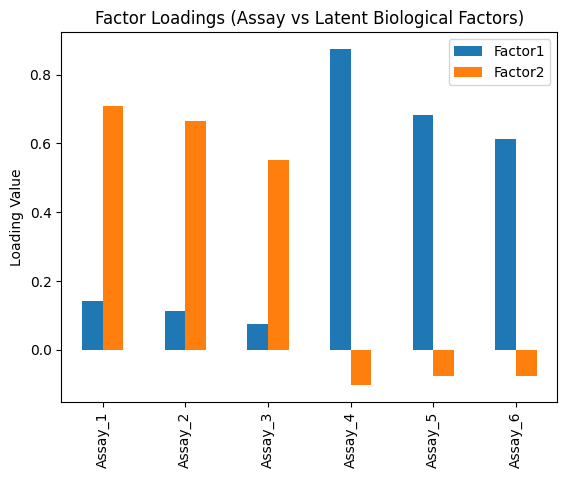

In [5]:
loadings.plot(kind="bar")
plt.title("Factor Loadings (Assay vs Latent Biological Factors)")
plt.ylabel("Loading Value")
plt.show()

## Interpretation
The factor loadings show how strongly each assay is linked to each latent biological factor. 

We expect Assay 1-3 are strongly associated with Factor 1, while assays 4-6 are strongly associated with Factor 2. This means that  1-3 likely measure the same biological pathway and 4-6 measure a different one. 

This could be useful in drug discovery as it may reduce redundancy in assays, helps identify mechanism of action, groups assays into biologically meaningful clusters, and could help guide compound prioritization. 

In this example 2 pathways are simuluated but in practice, the number of factors is not known beforehand so some approaches that can be applied are domain knowledge or a Scree plot. 

## Conclusion
To summarize: 
- Factor analysis reduces many variables into fewer hidden factors
- It helps uncover structure in data
- Key output is the factor loadings, which show relationships